In [27]:
import os
import sys
import swifter
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from bs4 import BeautifulSoup

import umap
import umap.plot

# 현재 노트북이 있는 경로 기준으로 프로젝트 루트(recsys) 경로 계산
current_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
project_root = os.path.abspath(os.path.join(current_dir, ".."))

# recsys 폴더를 sys.path에 추가
if project_root not in sys.path:
    sys.path.append(project_root)

from setup_env import setup_env

root_dir = setup_env()

from utils.dataset.config import DatasetPath
from utils.dataset.user_generator import generate_users
from utils.dataset.plot import show_items
from utils.retriever.ann import build_index, search

[INFO] Font applied: NanumGothic


# Dataset Path

In [28]:
# 데이터셋 경로
dataset_dir = Path(root_dir).joinpath("data/dataset")
paths = DatasetPath(root_dir=dataset_dir, dataset_name="fashion")

# User Metadata
- 가상의 유저 데이터 생성

In [3]:
# 중앙값 근처로 많이 생성되는 삼각분포(기본)
df_user = generate_users(
    num_users=10000,
    age_range=(18, 60),
    genders=("Men", "Women"),
    gender_probs=(0.5, 0.5),
    seed=42,
)

# ---------- 피크 나이를 30세로 명시 ---------- #
# df_user_30peak = generate_users(
#     num_users=10000, age_range=(18, 70), age_mode=30, seed=42
# )

# ---------- 기존 균등분포로 생성하고 싶다면 ---------- #
# df_user_uniform = generate_users(
#     num_users=10000, age_range=(18, 70), age_distribution="uniform", seed=42
# )

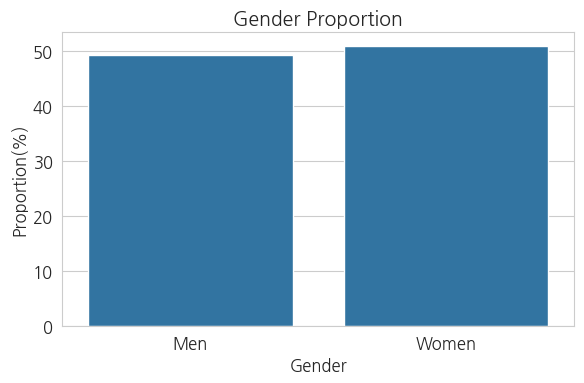

In [4]:
# 성별 분포
df_age_agg = df_user["gender"].value_counts(normalize=True).sort_index().reset_index()
df_age_agg["proportion"] = df_age_agg["proportion"] * 100

plt.figure(figsize=(6, 4), dpi=100)
sns.barplot(data=df_age_agg, x="gender", y="proportion")
plt.title("Gender Proportion", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Proportion(%)", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

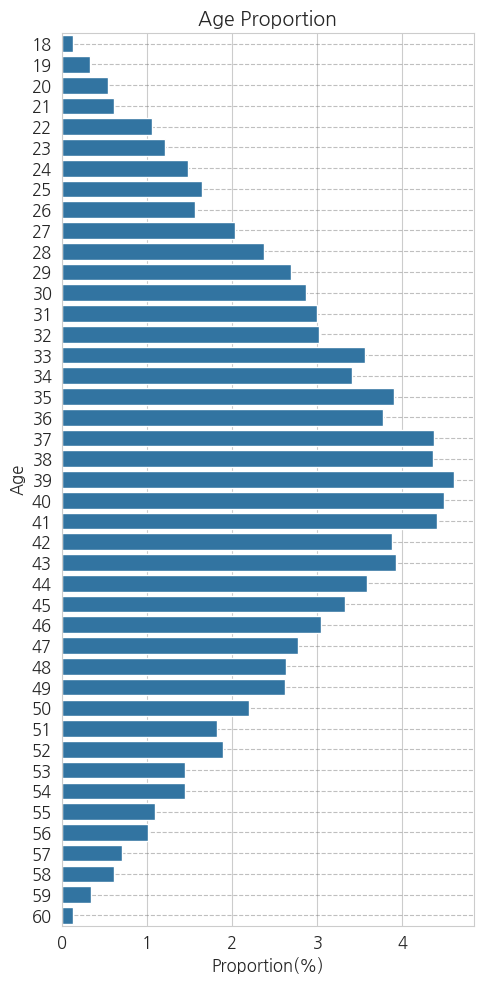

In [5]:
# 연령 분포
df_age_agg = df_user["age"].value_counts(normalize=True).sort_index().reset_index()
df_age_agg["age"] = df_age_agg["age"].astype(str)
df_age_agg["proportion"] = df_age_agg["proportion"] * 100

plt.figure(figsize=(5, 10), dpi=100)
sns.barplot(data=df_age_agg, x="proportion", y="age")
plt.title("Age Proportion", fontsize=14)
plt.xlabel("Proportion(%)", fontsize=12)
plt.ylabel("Age", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, axis="y", linestyle="--", color="grey", alpha=0.5)
plt.tight_layout()
plt.show()

In [6]:
df_user.to_parquet(paths.user_metadata_path)

# Item Metadata
- https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-dataset/data

In [7]:
df_item = pd.read_parquet(paths.item_metadata_path)
df_item = df_item.sort_values("item_id", ignore_index=True)

In [8]:
df_item.columns

Index(['item_id', 'name', 'brand_name', 'price', 'discount_price', 'gender',
       'age_group', 'base_color', 'season', 'year', 'usage', 'master_category',
       'sub_category', 'article_type', 'fit', 'occasion', 'description'],
      dtype='object')

In [9]:
columns = [
    "gender",
    "age_group",
    "season",
    "year",
    "usage",
    "master_category",
    "fit",
    "occasion",
]

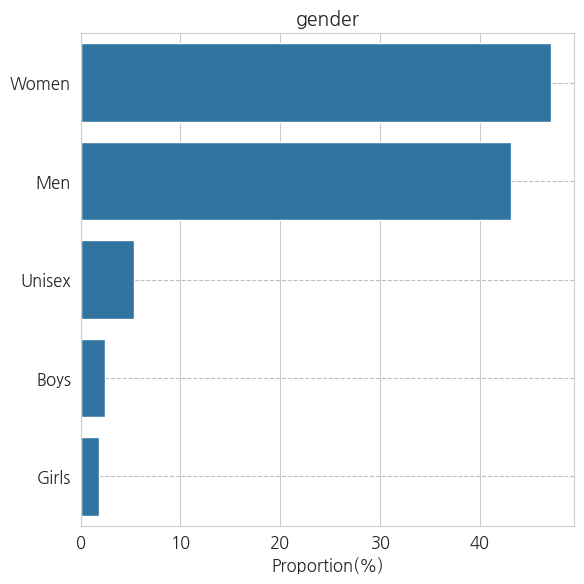

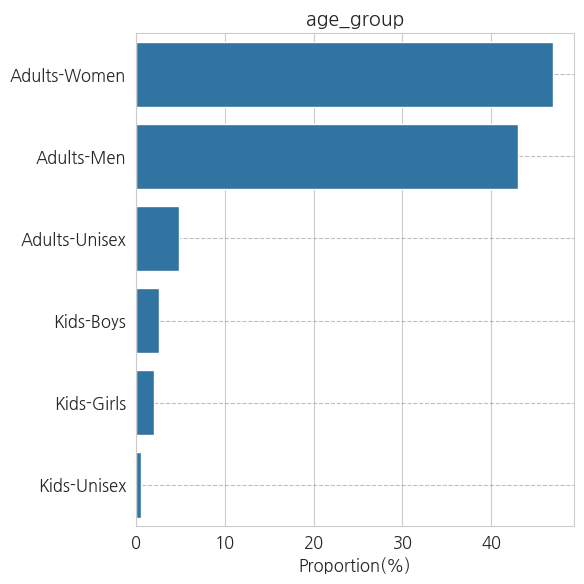

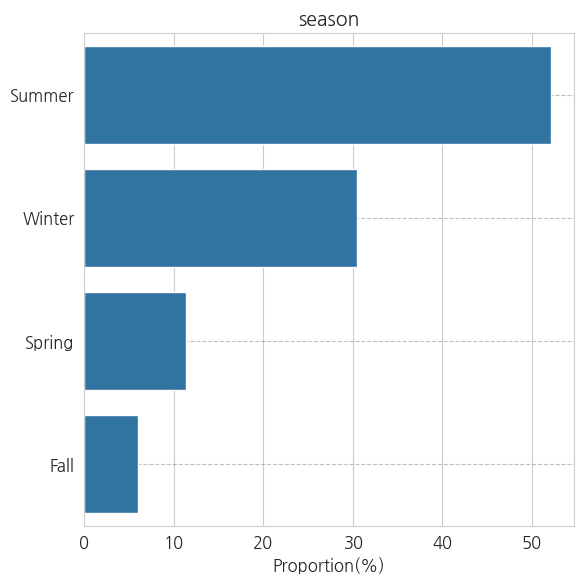

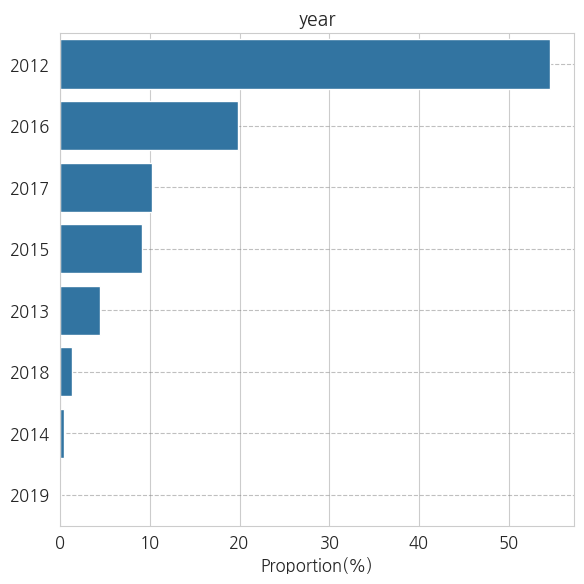

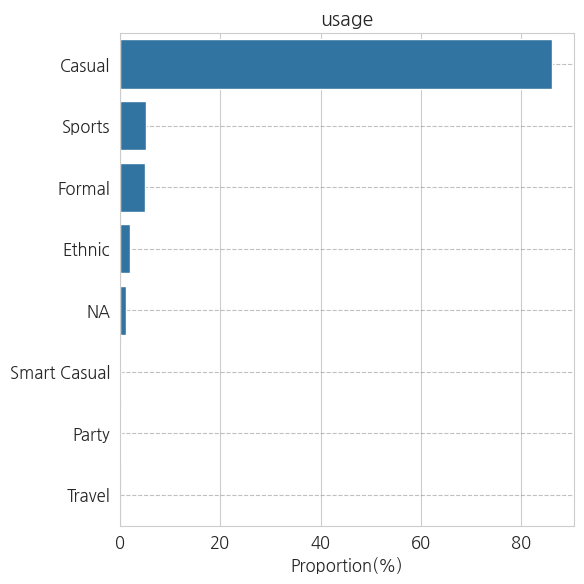

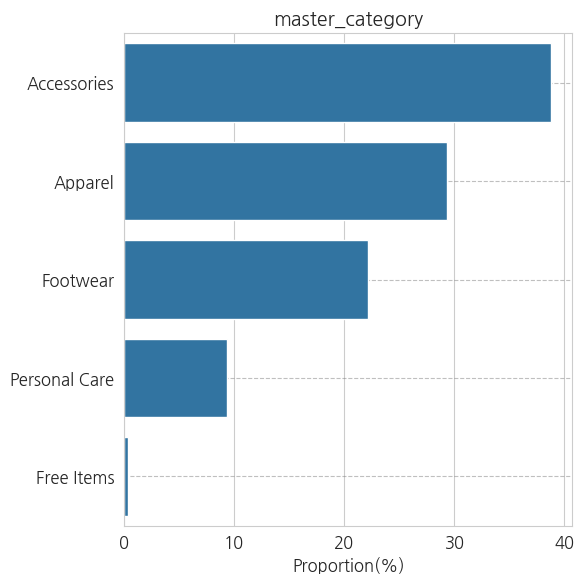

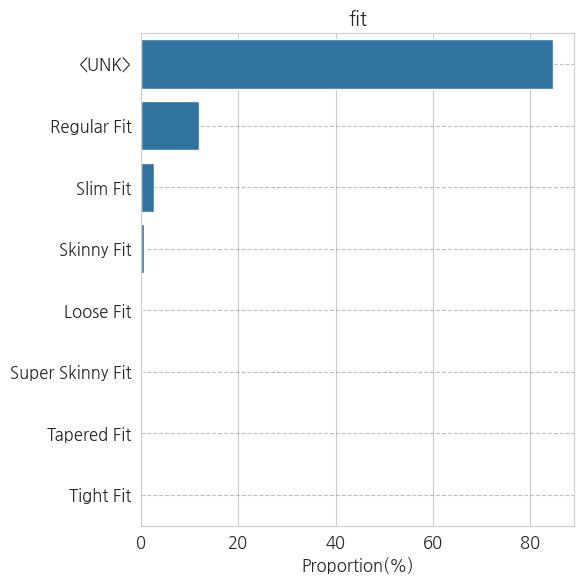

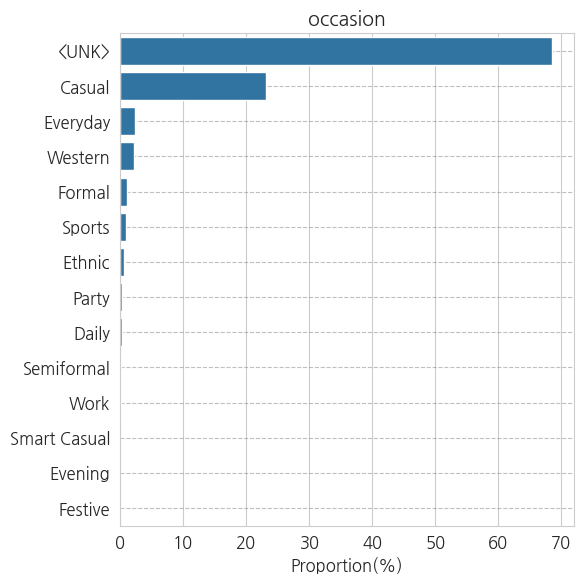

In [10]:
# 일부 데이터 분포 확인
for col in columns:
    # 필드별 비율 집계
    df_item[col].value_counts()
    df_agg = (
        df_item[col]
        .value_counts(normalize=True)
        .sort_values(ascending=False)
        .reset_index()
    )
    df_agg[col] = df_agg[col].astype(str)
    df_agg["proportion"] = df_agg["proportion"] * 100

    plt.figure(figsize=(6, 6), dpi=100)
    sns.barplot(data=df_agg, x="proportion", y=col)
    plt.title(f"{col}", fontsize=14)
    plt.xlabel("Proportion(%)", fontsize=12)
    plt.ylabel("")
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, axis="y", linestyle="--", color="grey", alpha=0.5)
    plt.tight_layout()
    plt.show()

# Item Vector

## Text Vector
- Vector Similarity Search 기반 추천을 위한 아이템 임베딩 벡터 생성

In [11]:
def clean_html_tags(text: str) -> str:
    """
    HTML 태그를 제거하고 순수 텍스트만 남기는 함수
    (<br>, <p>, <strong> 등의 태그를 모두 제거하며, HTML entity도 처리함)
    """

    # HTML 파싱
    soup = BeautifulSoup(text, "html.parser")

    # 텍스트 추출 + 불필요한 공백 정리
    cleaned = soup.get_text(separator=" ").strip()
    cleaned = " ".join(cleaned.split())  # 다중 공백 제거

    return cleaned


df_item["description_cleaned"] = df_item["description"].swifter.apply(
    lambda x: clean_html_tags(x)
)
df_item["name_and_description"] = df_item["name"] + ":" + df_item["description_cleaned"]

Pandas Apply:   0%|          | 0/10000 [00:00<?, ?it/s]

In [12]:
from sentence_transformers import SentenceTransformer

# -----------------------------------------------
# 텍스트 임베딩 모델 불러오기
# - "all-MiniLM-L6-v2": 소형 영문 문장 임베딩 모델
# - `normalize_embeddings=True`: 코사인 유사도를 위해 벡터를 정규화
# -----------------------------------------------
# model = SentenceTransformer("all-MiniLM-L6-v2")
model = SentenceTransformer("all-mpnet-base-v2")

# 아이템 제목을 벡터로 변환
text_vectors = model.encode(df_item["name"].tolist(), normalize_embeddings=True)
df_text_vectors = pd.DataFrame(
    {
        "item_id": df_item["item_id"].tolist(),
        "text_vector": [vec.tolist() for vec in text_vectors],
    }
)
df_text_vectors.to_parquet(paths.text_vectors_path)

In [13]:
# ANN 빌드
text_vectors = np.array(text_vectors).astype("float32")
text_index = build_index(vectors=text_vectors)

In [14]:
# 벡터 유사도 검색
query_text = "white t-shirt"
query_vector = model.encode([query_text], normalize_embeddings=True).astype("float32")
result = search(index=text_index, query_vector=query_vector, top_k=5)
print(result)

[{1161: 0.7678297162055969, 4973: 0.7550424337387085, 7915: 0.7550424337387085, 5425: 0.7349002957344055, 6726: 0.7333637475967407}]


In [15]:
# 유사 상품 조회
item_id_map = {i: item_id for i, item_id in enumerate(df_item["item_id"].tolist())}
for rnk, (item_idx, score) in enumerate(result[0].items()):
    item_id = item_id_map[item_idx]
    item_name = df_item[df_item["item_id"] == item_id]["name"].item()
    print(f"{rnk+1}. {item_name} (score: {score:.4f})")

1. Basics Men White T-shirt (score: 0.7678)
2. Myntra Men White T-shirt (score: 0.7550)
3. Myntra Men White T-shirt (score: 0.7550)
4. Proline Men White Polo T-Shirt (score: 0.7349)
5. Reebok Men Star White Polo T-shirt (score: 0.7334)


In [16]:
# UMAP 기반 차원 축소
# - metric="cosine": 임베딩 간 코사인 거리 기준으로 구조를 보존
reducer = umap.UMAP(metric="cosine", n_neighbors=30, n_components=2, random_state=42)

# 벡터 차원 축소 (예: 768차원 -> 2차원)
embeddings = reducer.fit_transform(text_vectors)

/Users/hwangyungwan/miniforge3/envs/ds_p313/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


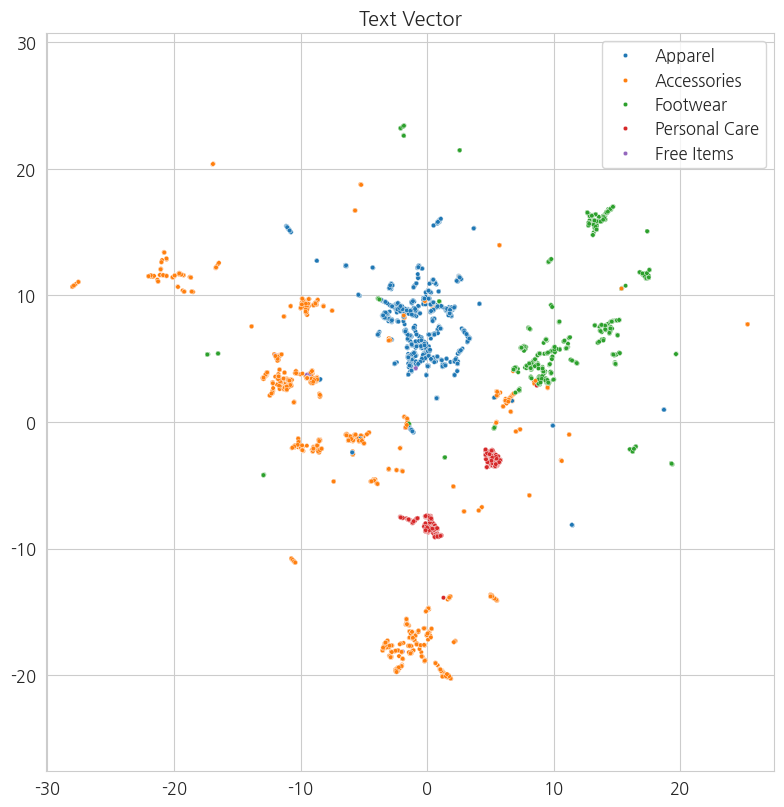

In [17]:
plt.figure(figsize=(8, 8))

# UMAP 결과를 산점도로 표현
# - x축: 축소된 첫 번째 차원
# - y축: 축소된 두 번째 차원
# - s=10: 점 크기
# - legend=Ture: 범례 사용
df_tmp = df_text_vectors.merge(df_item, on="item_id", how="left")
hue = df_tmp["master_category"].tolist()
sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], s=10, legend=True, hue=hue)

# 축 비율을 동일하게 설정 (왜곡 방지)
plt.gca().set_aspect("equal", "datalim")

# 여백 자동 조정
plt.tight_layout()

plt.title("Text Vector")
plt.show()

## Image Vector
- Vector Similarity Search 기반 추천을 위한 아이템 임베딩 벡터 생성

In [18]:
# ===================================================================
# 이미지 벡터 생성은 구글 코랩(Colab) GPU를 사용하여 실행
# ===================================================================

# import os
# import numpy as np
# import pandas as pd
# from tqdm import tqdm
#
# import torch
# from PIL import Image
# from transformers import CLIPProcessor, CLIPModel
#
#
# # -----------------------------------------------
# # 이미지 경로 설정
# # -----------------------------------------------
# from google.colab import drive
#
# drive.mount("/content/drive", force_remount=True)
#
# image_dir = "/content/drive/MyDrive/recsys/dataset/fashion/images"
#
# image_paths = [
#     os.path.join(image_dir, f)
#     for f in os.listdir(image_dir)
#     if f.lower().endswith(".jpg")
# ]
# print(f"[INFO] 총 이미지 수: {len(image_paths)}")
#
#
# # -----------------------------------------------
# # 모델 로드
# # -----------------------------------------------
# device = "cuda" if torch.cuda.is_available() else "cpu"
# print(f"[INFO] Using device: {device}")
#
# model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(device)
# processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")
#
#
# def encode_images(image_paths, batch_size=128):
#     all_embeddings = []
#     all_filenames = []
#     for i in tqdm(range(0, len(image_paths), batch_size)):
#         batch_paths = image_paths[i : i + batch_size]
#         batch_images = []
#         valid_paths = []
#         for p in batch_paths:
#             try:
#                 img = Image.open(p).convert("RGB")
#                 batch_images.append(img)
#                 valid_paths.append(p)
#             except Exception as e:
#                 print(f"[WARN] Failed to load {p}: {e}")
#
#         if not batch_images:
#             continue
#
#         inputs = processor(images=batch_images, return_tensors="pt", padding=True).to(
#             device
#         )
#
#         with torch.no_grad():
#             outputs = model.get_image_features(**inputs)
#             embeddings = outputs / outputs.norm(dim=-1, keepdim=True)  # L2 정규화
#             embeddings = embeddings.cpu().numpy()
#
#         all_embeddings.append(embeddings)
#         all_filenames.extend(valid_paths)
#
#     return np.vstack(all_embeddings).astype("float32"), all_filenames
#
#
# # -----------------------------------------------
# # 임베딩 벡터 추출 및 저장
# # -----------------------------------------------
# embeddings, valid_paths = encode_images(image_paths, batch_size=256)
# df_image_vectors = pd.DataFrame(
#     {
#         "item_id": [int(x.split("/")[-1].replace(".jpg", "")) for x in valid_paths],
#         "image_vector": embeddings.tolist(),
#     }
# )
#
# output_path = "/content/drive/MyDrive/recsys/dataset/fashion/image_vectors.parquet"
# df_image_vectors.to_parquet(output_path)

In [19]:
# -----------------------------------------------
# 구글 코랩(Colab)에서 실행하여 완성된 파일을 다운로드 후 로드
# (파일을 미리 제공하므로 별도 실행 불필요)
# -----------------------------------------------
df_image_vectors = pd.read_parquet(paths.image_vectors_path)
df_image_vectors = df_image_vectors.sort_values("item_id", ignore_index=True)
item_id_map = {
    i: item_id for i, item_id in enumerate(df_image_vectors["item_id"].tolist())
}
image_vectors = np.array(df_image_vectors["image_vector"].tolist())

In [20]:
# ANN 빌드
image_index = build_index(image_vectors)

In [21]:
image_dir = dataset_dir.joinpath("fashion/images")

[입력 이미지]: Wildcraft Zoomer Green Backpack)


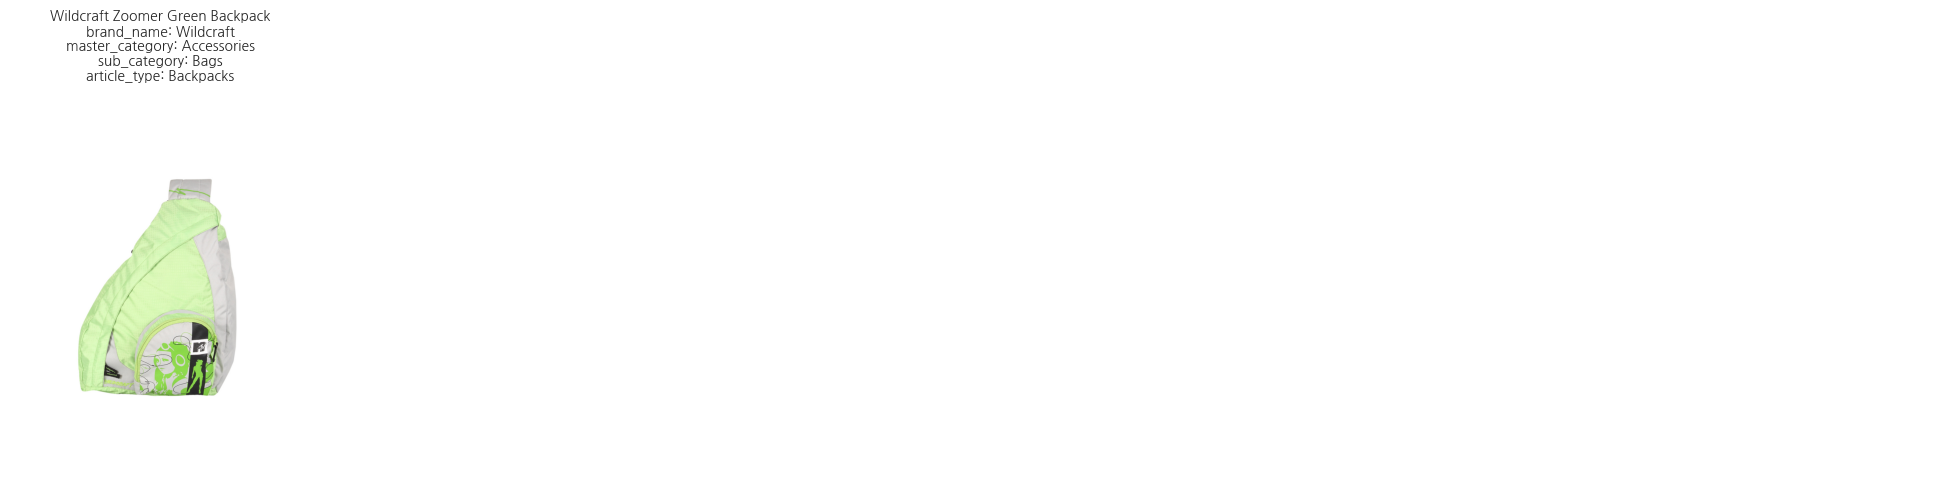

In [22]:
idx = 1

item_id = df_image_vectors.iloc[idx]["item_id"].item()
query_vector = df_image_vectors.iloc[idx]["image_vector"].reshape(1, -1)
print(f"[입력 이미지]: {df_item[df_item['item_id'] == item_id]['name'].values[0]})")
show_items(item_ids=[item_id], df_item=df_item, image_dir=image_dir)

In [23]:
result = search(index=image_index, query_vector=query_vector, top_k=5)
print(result)

[{1: 1.0000001192092896, 1958: 0.8190449476242065, 820: 0.8082550168037415, 5149: 0.7763245105743408, 9385: 0.7728490829467773}]


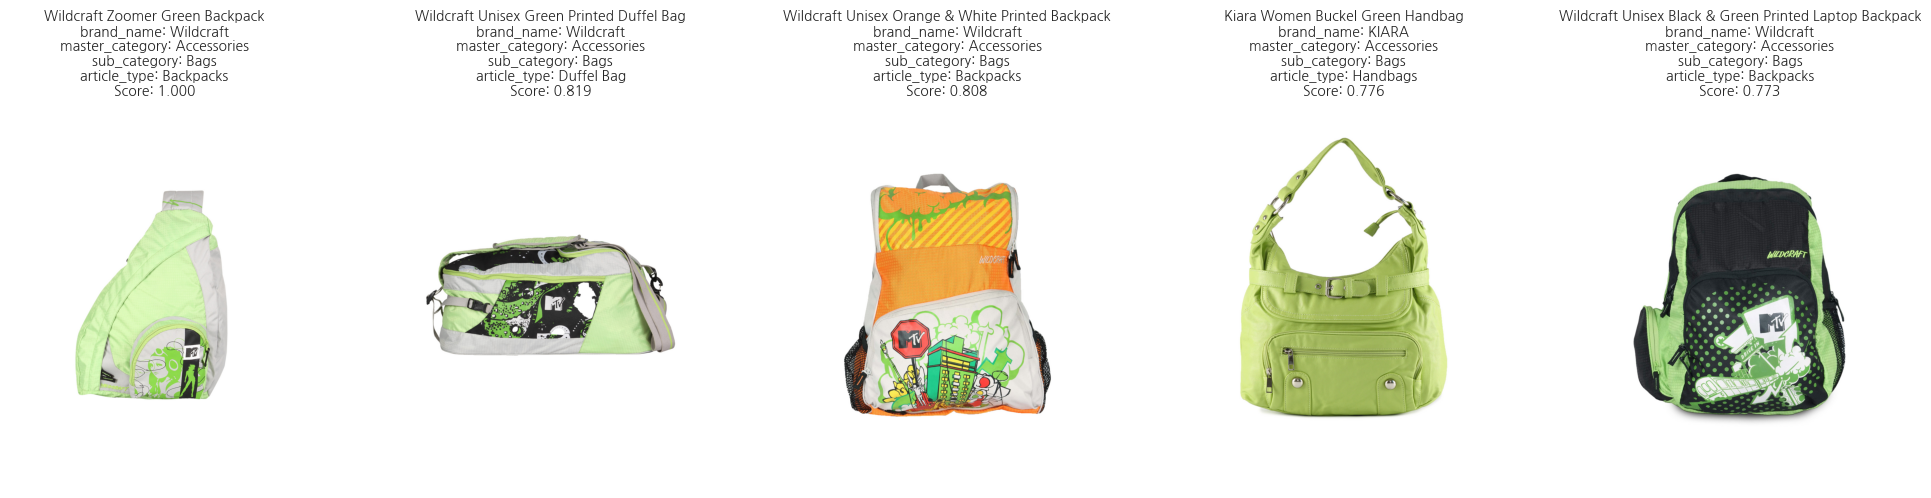

In [24]:
item_ids = [item_id_map[item_idx] for item_idx in result[0].keys()]
show_items(
    df_item=df_item,
    item_ids=item_ids,
    image_dir=image_dir,
    scores=list(result[0].values()),
)

In [25]:
# UMAP 기반 차원 축소
# - metric="cosine": 임베딩 간 코사인 거리 기준으로 구조를 보존
reducer = umap.UMAP(metric="cosine", n_neighbors=30, n_components=2, random_state=42)

# 벡터 차원 축소 (예: 768차원 -> 2차원)
embeddings = reducer.fit_transform(image_vectors)

/Users/hwangyungwan/miniforge3/envs/ds_p313/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


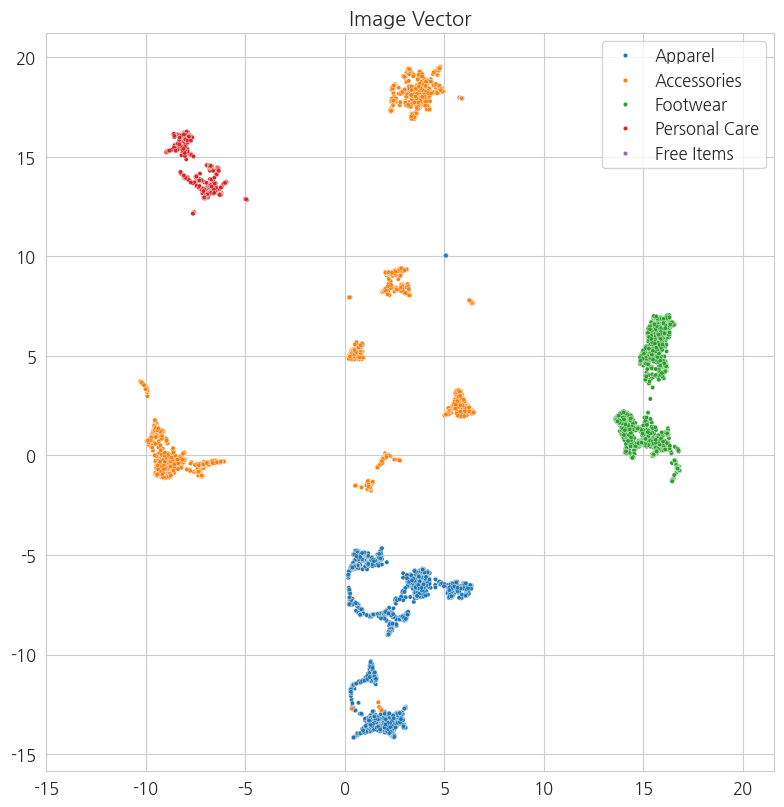

In [26]:
plt.figure(figsize=(8, 8))

# UMAP 결과를 산점도로 표현
# - x축: 축소된 첫 번째 차원
# - y축: 축소된 두 번째 차원
# - s=10: 점 크기
# - legend=Ture: 범례 사용
df_tmp = df_image_vectors.merge(df_item, on="item_id", how="left")
hue = df_tmp["master_category"].tolist()
sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], s=10, legend=True, hue=hue)

# 축 비율을 동일하게 설정 (왜곡 방지)
plt.gca().set_aspect("equal", "datalim")

# 여백 자동 조정
plt.tight_layout()

plt.title("Image Vector")
plt.show()